In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

[INFO] Fetching Pima Indians Diabetes dataset...
[INFO] Training SVMs with different C values...


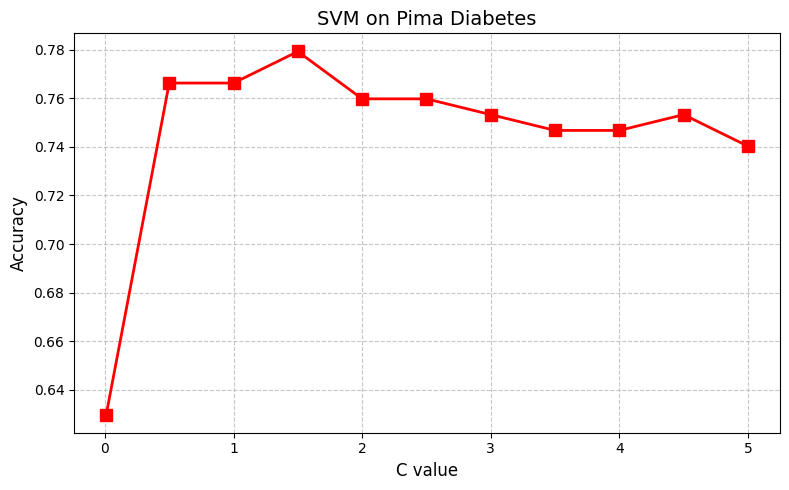

In [2]:

print("[INFO] Fetching Pima Indians Diabetes dataset...")

diabetes = fetch_openml(name='diabetes', version=1, as_frame=True, parser='auto')
X_dib = diabetes.data
y_dib = (diabetes.target == 'tested_positive').astype(int) 

X_train_dib, X_test_dib, y_train_dib, y_test_dib = train_test_split(X_dib, y_dib, test_size=0.2, random_state=2021)
scaler_dib = StandardScaler()
X_train_dib_scaled = scaler_dib.fit_transform(X_train_dib)
X_test_dib_scaled = scaler_dib.transform(X_test_dib)

print("[INFO] Training SVMs with different C values...")

c_values = [0.01, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
accuracies_dib = []

for c in c_values:
    svm_dib = SVC(C=c, random_state=2021)
    svm_dib.fit(X_train_dib_scaled, y_train_dib)
    acc = accuracy_score(y_test_dib, svm_dib.predict(X_test_dib_scaled))
    accuracies_dib.append(acc)


plt.figure(figsize=(8, 5))
plt.plot(c_values, accuracies_dib, marker='s', linestyle='-', color='red', linewidth=2, markersize=8)
plt.title("SVM on Pima Diabetes", size=14)
plt.xlabel("C value", size=12)
plt.ylabel("Accuracy", size=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()